In [ ]:
import asyncio
import sys
import random # Para simular comportamiento humano
from playwright.async_api import async_playwright
import pandas as pd

if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

async def ejecutar_extraccion(url):
    try:
        async with async_playwright() as p:
            user_data_dir = r"C:\Users\resqu\AppData\Local\BraveSoftware\Brave-Browser\User Data"
            brave_path = r"C:\Program Files\BraveSoftware\Brave-Browser\Application\brave.exe"

            print("--- Iniciando Extraccion por Goteo (Mas lento, mas seguro) ---")
            
            context = await p.chromium.launch_persistent_context(
                user_data_dir,
                executable_path=brave_path,
                headless=False,
                args=["--profile-directory=Default"]
            )
            
            page = await context.new_page()
            await page.goto(url, wait_until="domcontentloaded")
            await page.wait_for_selector('div[lang]', timeout=30000)

            await page.evaluate("""
                window.bolsa = new Set();
                const observer = new MutationObserver(() => {
                    document.querySelectorAll('div[lang]').forEach(n => {
                        let txt = n.innerText.trim();
                        if(txt.length > 35 && !txt.includes("To view keyboard")) {
                            window.bolsa.add(txt);
                        }
                    });
                });
                observer.observe(document.body, {childList: true, subtree: true});
            """)

            # --- ESTRATEGIA DE SCROLL POR GOTEO ---
            # Hacemos mas pasos, pero mas cortos
            for i in range(120): 
                # Scroll mas corto (600px) para no saltarnos comentarios
                await page.mouse.wheel(0, 600)
                
                # Tiempo aleatorio entre 3 y 6 segundos (Simula lectura humana)
                espera = random.uniform(3, 6)
                await asyncio.sleep(espera) 
                
                total = await page.evaluate("window.bolsa.size")
                print(f"--- Paso {i+1}/120 | Acumulados: {total} | Espera: {espera:.1f}s ---")
                
                # Pequeño scroll hacia ARRIBA a veces para "engañar" al detector de bots
                if i % 10 == 0:
                    await page.mouse.wheel(0, -200)
                    await asyncio.sleep(1)

            datos_finales = await page.evaluate("Array.from(window.bolsa)")
            await context.close()
            return datos_finales
            
    except Exception as e:
        print(f"--- Error: {str(e)} ---")
        return []

async def main():
    url_objetivo = "https://x.com/JMilei/status/189638057367057216608"
    comentarios = await ejecutar_extraccion(url_objetivo)
    
    if comentarios:
        df = pd.DataFrame(comentarios, columns=["Contenido_Comentario"])
        df = df.drop_duplicates()
        df.to_csv("comentarios_masivos_x.csv", index=False, encoding='utf-8-sig')
        print(f"\nProceso terminado. Total final: {len(df)} comentarios.")
    else:
        print("--- No se capturaron datos ---")

if __name__ == "__main__":
    asyncio.run(main())


In [3]:
import pandas as pd
import re

def limpiar_texto(texto):
    #Convertir a minúsculas
    texto = texto.lower()
    #Eliminar URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)
    #Eliminar menciones (@usuario) y hashtags (#)
    texto = re.sub(r'@\w+|#\w+', '', texto)
    #Eliminar caracteres especiales y números (opcional, deja letras y espacios)
    texto = re.sub(r'[^\w\s]', '', texto)
    #Eliminar espacios en blanco extra
    texto = texto.strip()
    return texto

#Cargar el archivo sucio que generó tu script
df = pd.read_csv('E:/CIENCIA DE DATOS E IA/2-SEGUNDO AÑO/SEGUNDO CUATRIMESTRE/1- ARQUITECTURA DE SOLUCIONES/csvsucio.csv', names=['comentario'])

#Aplicar limpieza
print(f"Registros iniciales: {len(df)}")

#Eliminar duplicados exactos
df = df.drop_duplicates()

#Aplicar la función de limpieza
df['comentario_limpio'] = df['comentario'].apply(limpiar_texto)

#Filtrar: quedarnos solo con comentarios de más de 35 caracteres (como decía tu Portafolio 02)
df = df[df['comentario_limpio'].str.len() > 35]

print(f"Registros después de la limpieza: {len(df)}")

#Guardar el archivo listo para el análisis de sentimientos
df.to_csv("comentario_limpio.csv", index=False, encoding='utf-8-sig')

Registros iniciales: 191
Registros después de la limpieza: 183


In [ ]:
# Instalar pip install textblob desde la terminal

In [6]:
import pandas as pd
from textblob import TextBlob
import os

# 1. Verificación de existencia del archivo
archivo_entrada = 'comentario_limpio.csv'

if not os.path.exists(archivo_entrada):
    print(f"ERROR: No se encuentra el archivo '{archivo_entrada}' en la carpeta actual.")
    print("Asegúrate de que el archivo generado en el paso anterior tenga exactamente ese nombre.")
else:
    # 2. Carga flexible del CSV
    # Cargamos el archivo y dejamos que pandas detecte las columnas
    df = pd.read_csv(archivo_entrada, encoding='utf-8-sig')
    
    # Seleccionamos la columna que vamos a procesar
    # Si existe 'Contenido_Comentario' la usa, sino, usa la primera columna disponible
    columna_texto = 'Contenido_Comentario' if 'Contenido_Comentario' in df.columns else df.columns[0]
    
    print(f"Procesando sentimientos usando la columna: '{columna_texto}'")

    def analizar_sentimiento(texto):
        if not isinstance(texto, str) or texto.strip() == "":
            return "Neutro"
        # Análisis con TextBlob
        analisis = TextBlob(texto)
        if analisis.sentiment.polarity > 0:
            return 'Positivo'
        elif analisis.sentiment.polarity < 0:
            return 'Negativo'
        else:
            return 'Neutro'

    # 3. Aplicar el análisis
    df['Sentimiento'] = df[columna_texto].apply(analizar_sentimiento)

    # 4. Guardar el resultado final
    archivo_salida = 'resultado_final_analisis.csv'
    df.to_csv(archivo_salida, index=False, encoding='utf-8-sig')

    print(f"¡Proceso completado! Archivo '{archivo_salida}' generado.")
    print("\nResumen de Sentimientos:")
    print(df['Sentimiento'].value_counts())

Procesando sentimientos usando la columna: 'comentario'
¡Proceso completado! Archivo 'resultado_final_analisis.csv' generado.

Resumen de Sentimientos:
Sentimiento
Neutro      167
Positivo     10
Negativo      6
Name: count, dtype: int64


Imagen 'grafico_sentimientos.png' generada.


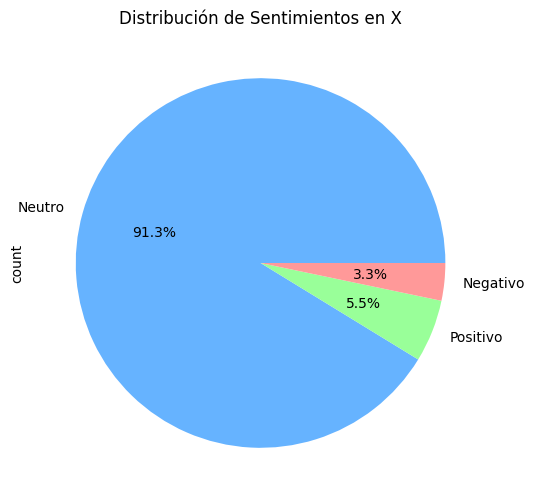

In [7]:
import matplotlib.pyplot as plt

# ... (después de generar el df['Sentimiento'])

# Crear gráfico de torta
plt.figure(figsize=(8, 6))
df['Sentimiento'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ff9999'])
plt.title('Distribución de Sentimientos en X')

# Guardar como imagen
plt.savefig('grafico_sentimientos.png')
print("Imagen 'grafico_sentimientos.png' generada.")